In [4]:
import pandas as pd
import os
import joblib
from collections import defaultdict

# === Paths ===
clinical_base = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new"
pathology_base = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_cerad"
gwas_path = "/n/scratch/users/a/adm808/MONDO_0004975_associations_export.tsv"
gtex_dir = "/n/scratch/users/a/adm808/GTEx_Analysis_v10_eQTL_updated"

cell_types = ['Ast', 'Mic', 'In', 'Oli', 'Opc', 'Ex']

# === Load GWAS gene → rsID mapping ===
gwas_df = pd.read_csv(gwas_path, sep="\t", low_memory=False)
gwas_df["clean_rsid"] = gwas_df["riskAllele"].str.split("-").str[0]

gene_to_rsids = defaultdict(set)
for _, row in gwas_df.iterrows():
    rsid = row["clean_rsid"]
    genes = str(row["mappedGenes"]).split(",")
    for gene in genes:
        gene = gene.strip().upper()
        if gene and rsid.startswith("rs"):
            gene_to_rsids[gene].add(rsid)

# === Load GTEx rsIDs ===
eqtl_rsids = set()
for fname in os.listdir(gtex_dir):
    if fname.endswith(".gz"):
        df = pd.read_csv(os.path.join(gtex_dir, fname), sep="\t", compression="gzip")
        if "rs_id_dbSNP155_GRCh38p13" not in df.columns:
            continue
        rsids = df["rs_id_dbSNP155_GRCh38p13"].str.split("_").str[0]
        eqtl_rsids.update(rsids)

# === Load predictors for each cell type ===
def load_predictors(base_dir):
    predictors_by_type = {}
    for ct in cell_types:
        gene_presence = defaultdict(int)
        for split in range(1, 6):
            clf_path = os.path.join(base_dir, ct, f"split_{split}", "maximal_classifier.joblib")
            if not os.path.exists(clf_path):
                continue
            model = joblib.load(clf_path)
            for feat, imp in zip(model.feature_names_in_, model.feature_importances_):
                if imp > 0 and not (
                    feat.lower().startswith("age_death")
                    or feat.lower().startswith("msex")
                    or feat.lower().startswith("apoe_geno")
                    or feat.lower().startswith("educ")
                ):
                    gene_presence[feat.upper()] += 1
        predictors_by_type[ct] = {gene for gene, count in gene_presence.items() if count >= 2}
    return predictors_by_type

clinical_preds = load_predictors(clinical_base)
pathology_preds = load_predictors(pathology_base)

# === Get union of predictors across models ===
all_predictors = set()
for ct in cell_types:
    all_predictors |= clinical_preds[ct]
    all_predictors |= pathology_preds[ct]

# === Keep only predictors with GWAS+eQTL support ===
supported_genes = set()
gene_to_supported_rsids = defaultdict(set)

for gene in all_predictors:
    if gene in gene_to_rsids:
        snps = gene_to_rsids[gene] & eqtl_rsids
        if snps:
            supported_genes.add(gene)
            gene_to_supported_rsids[gene] = snps

# === Flatten rsIDs into a list for LDpair ===
all_rsids_to_check = sorted({rsid for snps in gene_to_supported_rsids.values() for rsid in snps})

# === Save to file ===
pd.Series(all_rsids_to_check, name="rsID").to_csv("rsids_for_ldpair.txt", index=False)
print(f"[DONE] Saved {len(all_rsids_to_check)} rsIDs to rsids_for_ldpair.txt")

/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.5.1 w

[DONE] Saved 72 rsIDs to rsids_for_ldpair.txt


/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.5.1 wh

[STEP 1] Load reproducible predictors...
Total predictor rows: 2367 (unique genes across CTs: 1849)
[STEP 2] Load symbol↔Ensembl mapping...
[STEP 3] Load GTEx eGenes for selected brain tissues...
[STEP 4] Load AD GWAS genome-wide significant genes...
[OUTPUT] Master table → /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure10/predictors_eqtl_gwas_master_table.csv
[OUTPUT] Tier counts per cell type → /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure10/tier_counts_per_celltype.csv


/tmp/ipykernel_2400814/2744794387.py:126: RuntimeWarning: divide by zero encountered in log10
  rows.append({"Gene": gsym, "GWAS_P": pval, "-log10_P": -np.log10(pval)})


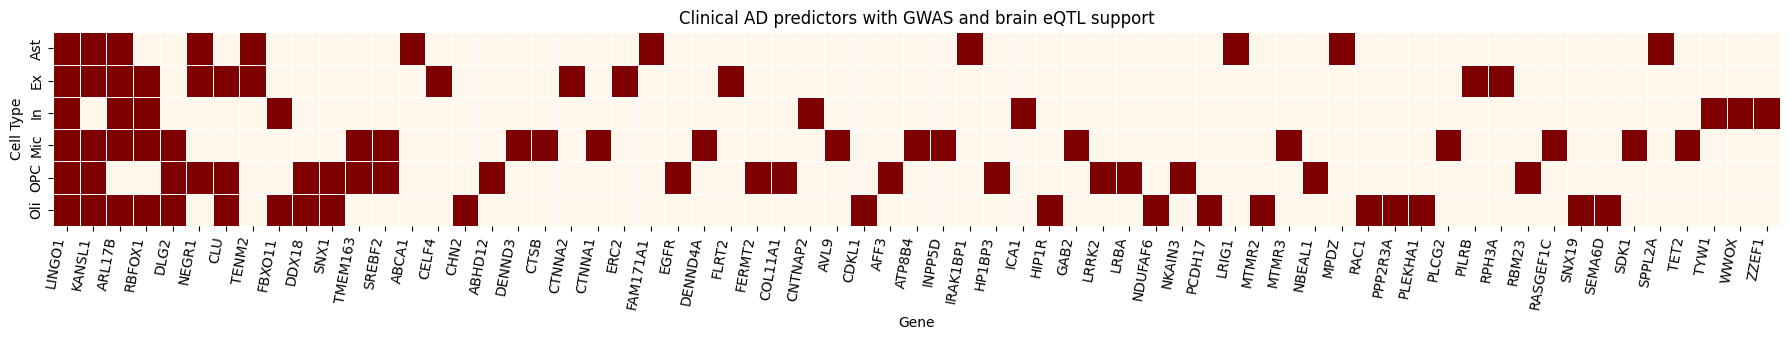

[OUTPUT] Heatmap → /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure10/clinical_tier3_eqtl_gwas_heatmap.png
[OUTPUT] Predictors by cell type → /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure10/predictors_by_celltype.csv
Done.


In [5]:
import os
import gzip
import numpy as np
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

# ============== CONFIG ==============
base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new"
gwas_path = "/n/scratch/users/a/adm808/MONDO_0004975_associations_export.tsv"
mapping_tsv_path = "/n/groups/patel/randy/single_cell/syn18485175/data/notfiltered_gene_row_names.txt"
gtex_dir = "/n/scratch/users/a/adm808/GTEx_Analysis_v10_eQTL_updated"
output_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure10"
os.makedirs(output_dir, exist_ok=True)

# tissues to check (extendable)
tissue_to_file = {
    "Brain_Cortex": "Brain_Cortex.v10.eGenes.txt.gz",
    "Brain_Anterior_cingulate_cortex_BA24": "Brain_Anterior_cingulate_cortex_BA24.v10.eGenes.txt.gz",
    "Brain_Frontal_Cortex_BA9": "Brain_Frontal_Cortex_BA9.v10.eGenes.txt.gz",
}

ct_labels = {
    'Ast': 'Ast',
    'Mic': 'Mic',
    'In': 'In',
    'Oli': 'Oli',
    'Opc': 'OPC',
    'Ex': 'Ex'
}
cell_types = list(ct_labels.keys())

# predictor reproducibility threshold
min_splits = 2

# exclude non-gene features by prefix
exclude_prefixes = ("age_death", "msex", "apoe_geno", "educ")

# GWAS significance
gw_sig_thr = 5e-8

# Optional: symbol aliasing (kept empty by default; add pairs if needed)
symbol_alias = {
    # "RASGEF1B": "RASGEF1B",  # example; no special-case unless you want it
}

# ============== HELPERS ==============
def load_predictors(base_dir, cell_types, min_splits=2, exclude_prefixes=()):
    """Return dict: ct -> list of reproducible predictive genes."""
    pred = {}
    for ct in cell_types:
        gene_presence = defaultdict(int)
        for split in range(1, 6):
            clf_path = os.path.join(base_dir, ct, f"split_{split}", "maximal_classifier.joblib")
            if not os.path.exists(clf_path):
                continue
            model = joblib.load(clf_path)
            feats = getattr(model, "feature_names_in_", None)
            imps  = getattr(model, "feature_importances_", None)
            if feats is None or imps is None:
                continue
            for f, w in zip(feats, imps):
                fl = f.lower()
                if w > 0 and not any(fl.startswith(p) for p in exclude_prefixes):
                    gene_presence[f] += 1
        # reproducibility filter
        genes = [g for g, c in gene_presence.items() if c >= min_splits]
        pred[ct] = sorted(genes)
    return pred

def load_symbol_to_ens(mapping_tsv_path):
    """mapping file with columns: EnsemblID, GeneSymbol (no header in your file)."""
    map_df = pd.read_csv(mapping_tsv_path, sep="\t", header=None, names=["EnsemblID", "GeneSymbol"])
    # strip version from Ensembl if present
    map_df["EnsemblID"] = map_df["EnsemblID"].astype(str).str.split(".").str[0]
    # normalize symbols to uppercase for matching, but keep original symbol for reporting
    map_df["GeneSymbolUpper"] = map_df["GeneSymbol"].astype(str).str.upper()
    # prefer one-to-one by first occurrence
    symbol_to_ens = dict(zip(map_df["GeneSymbolUpper"], map_df["EnsemblID"]))
    ens_to_symbol = dict(zip(map_df["EnsemblID"], map_df["GeneSymbol"]))
    return symbol_to_ens, ens_to_symbol

# def load_gtex_egenes(gtex_dir, tissue_to_file):
#     """Load GTEx eGene lists by tissue, return: dict(tissue -> set of Ensembl IDs)."""
#     gtex = {}
#     for tissue, fname in tissue_to_file.items():
#         path = os.path.join(gtex_dir, fname)
#         df = pd.read_csv(path, sep="\t", compression="gzip")
#         # GTEx v10 eGene files usually have 'gene_id' with version; strip it
#         if "gene_id" not in df.columns:
#             raise ValueError(f"'gene_id' not found in {path}")
#         df["gene_id"] = df["gene_id"].astype(str).str.split(".").str[0]
#         gtex[tissue] = set(df["gene_id"].values)
#     return gtex

def load_gtex_egenes(gtex_dir, tissue_to_file, fdr_threshold=0.05):
    gtex = {}
    for tissue, fname in tissue_to_file.items():
        path = os.path.join(gtex_dir, fname)
        df = pd.read_csv(path, sep="\t", compression="gzip")
        df["gene_id"] = df["gene_id"].astype(str).str.split(".").str[0]
        if "qval" in df.columns:
            df = df[df["qval"] < fdr_threshold]
        gtex[tissue] = set(df["gene_id"].values)  # always assign, even if empty
    return gtex

def load_gwas_genes(gwas_path, p_thr=5e-8, symbol_alias=None):
    """Return set of GWAS-significant genes (uppercased) and a dataframe of hits."""
    gwas = pd.read_csv(gwas_path, sep="\t", low_memory=False)
    rows = []
    for _, r in gwas.iterrows():
        pval_raw = r.get("pValue", None)
        try:
            pval = float(pval_raw) if pval_raw not in (None, "NR", "nan", np.nan) else None
        except Exception:
            pval = None
        if pval is None or pval >= p_thr:
            continue
        mapped = r.get("mappedGenes", "")
        genes = [g.strip().upper() for g in str(mapped).split(",") if g.strip()]
        if symbol_alias:
            genes = [symbol_alias.get(g, g) for g in genes]
        for gsym in genes:
            rows.append({"Gene": gsym, "GWAS_P": pval, "-log10_P": -np.log10(pval)})
    df = pd.DataFrame(rows)
    if df.empty:
        return set(), pd.DataFrame(columns=["Gene", "GWAS_P", "-log10_P"])
    # keep best p per gene
    df = df.sort_values("GWAS_P").drop_duplicates("Gene", keep="first")
    gset = set(df["Gene"].values)
    return gset, df

def upper(s):
    return str(s).upper()

# ============== PIPELINE ==============
print("[STEP 1] Load reproducible predictors...")
predictive_genes = load_predictors(base_dir, cell_types, min_splits=min_splits, exclude_prefixes=exclude_prefixes)

# explode into a table for auditing
pred_rows = []
for ct in cell_types:
    for gene in predictive_genes.get(ct, []):
        pred_rows.append({"CellType": ct_labels[ct], "GeneSymbol": gene, "GeneSymbolUpper": upper(gene)})
df_predictors = pd.DataFrame(pred_rows).drop_duplicates()

print(f"Total predictor rows: {len(df_predictors)} (unique genes across CTs: {df_predictors['GeneSymbolUpper'].nunique()})")

print("[STEP 2] Load symbol↔Ensembl mapping...")
symbol_to_ens, ens_to_symbol = load_symbol_to_ens(mapping_tsv_path)

# map Ensembl IDs for predictors
df_predictors["EnsemblID"] = df_predictors["GeneSymbolUpper"].map(symbol_to_ens)
df_predictors["HasEnsembl"] = df_predictors["EnsemblID"].notna()

print("[STEP 3] Load GTEx eGenes for selected brain tissues...")
gtex_egenes = load_gtex_egenes(gtex_dir, tissue_to_file)

# annotate per tissue eQTL presence
for tissue in tissue_to_file:
    df_predictors[f"eQTL_{tissue}"] = df_predictors["EnsemblID"].apply(
        lambda x: (x in gtex_egenes[tissue]) if pd.notna(x) else False
    )
# any eQTL across selected tissues
eqtl_cols = [c for c in df_predictors.columns if c.startswith("eQTL_")]
df_predictors["Any_eQTL_SelectedTissues"] = df_predictors[eqtl_cols].any(axis=1)

print("[STEP 4] Load AD GWAS genome-wide significant genes...")
gwas_gene_set, df_gwas_best = load_gwas_genes(gwas_path, p_thr=gw_sig_thr, symbol_alias=symbol_alias)

# annotate GWAS membership and bring min p
df_predictors["In_AD_GWAS"] = df_predictors["GeneSymbolUpper"].isin(gwas_gene_set)
df_predictors = df_predictors.merge(
    df_gwas_best.rename(columns={"Gene": "GeneSymbolUpper", "GWAS_P": "GWAS_P_min", "-log10_P": "GWAS_neglog10P_max"}),
    on="GeneSymbolUpper",
    how="left",
)

# Tiers:
#   Tier 1: Predictor only
#   Tier 2: Predictor + eQTL (any selected brain tissue)
#   Tier 3: Predictor + eQTL + AD GWAS p<5e-8
def assign_tier(row):
    if row["Any_eQTL_SelectedTissues"] and row["In_AD_GWAS"]:
        return "Tier3_Predictor+eQTL+GWAS"
    elif row["Any_eQTL_SelectedTissues"]:
        return "Tier2_Predictor+eQTL"
    else:
        return "Tier1_PredictorOnly"

df_predictors["Tier"] = df_predictors.apply(assign_tier, axis=1)

# save master table
master_path = os.path.join(output_dir, "predictors_eqtl_gwas_master_table.csv")
df_predictors.sort_values(["CellType", "Tier", "GeneSymbol"]).to_csv(master_path, index=False)
print(f"[OUTPUT] Master table → {master_path}")

# ============== SUMMARIES ==============
# per cell type tier counts
tier_counts = (
    df_predictors.groupby(["CellType", "Tier"])
    .size()
    .reset_index(name="N")
    .pivot(index="CellType", columns="Tier", values="N")
    .fillna(0)
    .astype(int)
    .reset_index()
)
tier_counts_path = os.path.join(output_dir, "tier_counts_per_celltype.csv")
tier_counts.to_csv(tier_counts_path, index=False)
print(f"[OUTPUT] Tier counts per cell type → {tier_counts_path}")

# ============== HEATMAP (Top GWAS-supported eQTL genes per CT) ==============
# Pick genes that are Tier3 and keep the best GWAS p per (Gene, CT)
tier3 = df_predictors[df_predictors["Tier"] == "Tier3_Predictor+eQTL+GWAS"].copy()
if not tier3.empty:
    # keep best p per GeneSymbolUpper across CTs (for ordering), but annotate per CT
    # Build a compact matrix: rows=CellType, cols=Gene, value = number of tissues with eQTL (0/1/2…)
    # restrict to top genes per CT by GWAS (min p)
    topN = 20
    # compute a small “eQTL count across selected tissues” per row
    tier3["eQTL_TissueCount"] = tier3[eqtl_cols].any(axis=1).astype(int)

    # choose topN genes per CT by smallest GWAS_P_min
    top_rows = (
        tier3.sort_values("GWAS_P_min", ascending=True)
             .drop_duplicates(subset=["CellType", "GeneSymbolUpper"], keep="first")
             .groupby("CellType")
             .head(topN)
    )
    # heatmap matrix
    heatmap_df = (
        top_rows
        .assign(GeneLabel = top_rows["GeneSymbol"].fillna(top_rows["GeneSymbolUpper"]))
        .pivot_table(index="CellType", columns="GeneLabel", values="eQTL_TissueCount", aggfunc="max", fill_value=0)
    )
    # order genes by how broadly they show up (across CTs), then by CT total
    gene_order = heatmap_df.astype(bool).sum(axis=0).sort_values(ascending=False).index
    heatmap_df = heatmap_df[gene_order]

    plt.figure(figsize=(18, 3.5))
    sns.heatmap(
        heatmap_df,
        cmap="OrRd",
        linewidths=0.5,
        cbar=False
    )
    plt.title("Clinical AD predictors with GWAS and brain eQTL support")
    plt.ylabel("Cell Type")
    plt.xlabel("Gene")
    plt.xticks(rotation=80, ha="right")
    plt.tight_layout()
    fig_path = os.path.join(output_dir, "clinical_tier3_eqtl_gwas_heatmap.png")
    # plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"[OUTPUT] Heatmap → {fig_path}")
else:
    print("[INFO] No Tier 3 genes found; skipping heatmap.")

# ============== OPTIONAL: sanity CSVs ==============
# predictors per CT
pred_only = df_predictors[["CellType", "GeneSymbol", "EnsemblID", "Any_eQTL_SelectedTissues", "In_AD_GWAS", "GWAS_P_min", "Tier"]]
pred_ct_path = os.path.join(output_dir, "predictors_by_celltype.csv")
pred_only.sort_values(["CellType", "Tier", "GeneSymbol"]).to_csv(pred_ct_path, index=False)
print(f"[OUTPUT] Predictors by cell type → {pred_ct_path}")

print("Done.")

In [6]:
import pandas as pd
import os
import joblib
from collections import defaultdict

# === Paths ===
base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new"
gwas_path = "/n/scratch/users/a/adm808/MONDO_0004975_associations_export.tsv"
gtex_dir = "/n/scratch/users/a/adm808/GTEx_Analysis_v10_eQTL_updated"

cell_types = ['Ast', 'Mic', 'In', 'Oli', 'Opc', 'Ex']

# === STEP 1: Load classifier predictors ===
predictive_genes_dict = {}
for ct in cell_types:
    gene_presence = defaultdict(int)
    for split in range(1, 6):
        clf_path = os.path.join(base_dir, ct, f"split_{split}", "maximal_classifier.joblib")
        if not os.path.exists(clf_path):
            continue
        model = joblib.load(clf_path)
        for feat, imp in zip(model.feature_names_in_, model.feature_importances_):
            feat_lower = feat.lower()
            if imp > 0 and not (
                feat_lower.startswith("age_death") or
                feat_lower.startswith("msex") or
                feat_lower.startswith("apoe_geno") or
                feat_lower.startswith("educ")
            ):
                gene_presence[feat] += 1
    # Keep genes that appear in ≥2 splits
    predictors = [gene for gene, count in gene_presence.items() if count >= 2]
    predictive_genes_dict[ct] = predictors

# Get all unique predictor genes
all_predictors = set(g.upper() for genes in predictive_genes_dict.values() for g in genes)

# === STEP 2: Load and clean GWAS catalog ===
gwas_df = pd.read_csv(gwas_path, sep="\t", low_memory=False)
gwas_df["clean_rsid"] = gwas_df["riskAllele"].str.split("-").str[0]  # Clean rsID

# Build gene → rsID mapping
gene_to_rsids = {}
for _, row in gwas_df.iterrows():
    rsid = row.get("clean_rsid", "")
    genes = str(row.get("mappedGenes", "")).split(",")
    for gene in genes:
        gene = gene.strip().upper()
        if gene and rsid.startswith("rs"):
            gene_to_rsids.setdefault(gene, set()).add(rsid)

# === STEP 3: Match predictor genes to GWAS genes and collect rsIDs ===
matching_rsids = set()
for gene in all_predictors:
    if gene in gene_to_rsids:
        matching_rsids.update(gene_to_rsids[gene])

print(f"[INFO] Total unique predictor genes: {len(all_predictors)}")
print(f"[INFO] Total matching rsIDs from GWAS: {len(matching_rsids)}")

# === STEP 4: Check rsIDs in GTEx eQTLs (only selected tissues) ===
tissue_to_file = {
    # "Brain_Amygdala": "Brain_Amygdala.v10.eGenes.txt.gz",
    "Brain_Anterior_cingulate_cortex_BA24": "Brain_Anterior_cingulate_cortex_BA24.v10.eGenes.txt.gz",
    # "Brain_Caudate_basal_ganglia": "Brain_Caudate_basal_ganglia.v10.eGenes.txt.gz",
    # "Brain_Cerebellar_Hemisphere": "Brain_Cerebellar_Hemisphere.v10.eGenes.txt.gz",
    # "Brain_Cerebellum": "Brain_Cerebellum.v10.eGenes.txt.gz",
    "Brain_Cortex": "Brain_Cortex.v10.eGenes.txt.gz",
    "Brain_Frontal_Cortex_BA9": "Brain_Frontal_Cortex_BA9.v10.eGenes.txt.gz",
    # "Brain_Hippocampus": "Brain_Hippocampus.v10.eGenes.txt.gz",
    # "Brain_Hypothalamus": "Brain_Hypothalamus.v10.eGenes.txt.gz",
    # "Brain_Nucleus_accumbens_basal_ganglia": "Brain_Nucleus_accumbens_basal_ganglia.v10.eGenes.txt.gz",
    # "Brain_Putamen_basal_ganglia": "Brain_Putamen_basal_ganglia.v10.eGenes.txt.gz",
    # "Brain_Spinal_cord_cervical_c-1": "Brain_Spinal_cord_cervical_c-1.v10.eGenes.txt.gz",
    # "Brain_Substantia_nigra": "Brain_Substantia_nigra.v10.eGenes.txt.gz"
}

eqtl_rsids = set()
for tissue, fname in tissue_to_file.items():
    fpath = os.path.join(gtex_dir, fname)
    if not os.path.exists(fpath):
        continue
    df = pd.read_csv(fpath, sep="\t", compression="gzip")
    if "rs_id_dbSNP155_GRCh38p13" not in df.columns:
        continue
    rsids = df["rs_id_dbSNP155_GRCh38p13"].str.split("_").str[0]
    eqtl_rsids.update(rsids)

# === STEP 5: Intersect ===
overlapping_rsids = sorted(matching_rsids & eqtl_rsids)
print(f"[RESULT] Matching rsIDs also found in GTEx eQTLs: {len(overlapping_rsids)}")

# === STEP 6: Count how many unique predictor genes these rsIDs map to ===
rsid_to_genes = defaultdict(set)
for gene, rsid_set in gene_to_rsids.items():
    for rsid in rsid_set:
        rsid_to_genes[rsid].add(gene)

overlapping_genes = set()
for rsid in overlapping_rsids:
    overlapping_genes.update(rsid_to_genes.get(rsid, []))

print(f"[FINAL] Total unique predictor genes with GWAS+GTEx eQTL support: {len(overlapping_genes)}")
print("[GENES]")
for gene in sorted(overlapping_genes):
    print(gene)

[INFO] Total unique predictor genes: 1849
[INFO] Total matching rsIDs from GWAS: 455
[RESULT] Matching rsIDs also found in GTEx eQTLs: 5
[FINAL] Total unique predictor genes with GWAS+GTEx eQTL support: 7
[GENES]
APOE
CEP170
CLU
CTSB
PICALM
RNU6-560P
TOMM40


In [18]:
print("\n[PREDICTIVE COUNTS BY CELL TYPE]")
for ct in cell_types:
    ct_predictors = set(g.upper() for g in predictive_genes_dict.get(ct, []))
    overlap_count = len(ct_predictors & overlapping_genes)
    print(f"{ct}: {overlap_count} of {len(ct_predictors)} predictors overlap ({', '.join(sorted(ct_predictors & overlapping_genes))})")


[PREDICTIVE COUNTS BY CELL TYPE]
Ast: 0 of 175 predictors overlap ()
Mic: 4 of 466 predictors overlap (APOE, CEP170, CTSB, PICALM)
In: 0 of 108 predictors overlap ()
Oli: 1 of 621 predictors overlap (CLU)
Opc: 2 of 835 predictors overlap (CLU, PICALM)
Ex: 1 of 162 predictors overlap (CLU)


[STEP 1] Load reproducible predictors...


/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.5.1 w

Total predictor rows: 1297 (unique genes across CTs: 1101)
[STEP 2] Load symbol↔Ensembl mapping...
[STEP 3] Load GTEx eGenes for selected brain tissues...
[STEP 4] Load AD GWAS genome-wide significant genes...
[OUTPUT] Master table → /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure10/predictors_eqtl_gwas_master_table.csv
[OUTPUT] Tier counts per cell type → /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure10/tier_counts_per_celltype.csv


/tmp/ipykernel_2400814/3419157673.py:126: RuntimeWarning: divide by zero encountered in log10
  rows.append({"Gene": gsym, "GWAS_P": pval, "-log10_P": -np.log10(pval)})


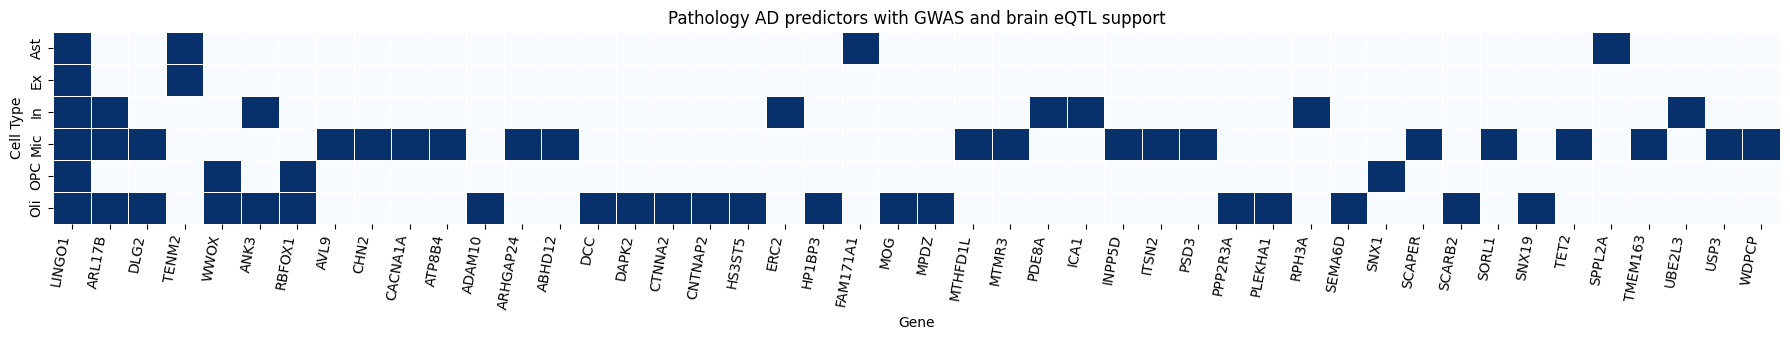

[OUTPUT] Heatmap → /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure10/cerad_tier3_eqtl_gwas_heatmap.png
[OUTPUT] Predictors by cell type → /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure10/predictors_by_celltype.csv
Done.


In [1]:
import os
import gzip
import numpy as np
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

# ============== CONFIG ==============
base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_cerad"
gwas_path = "/n/scratch/users/a/adm808/MONDO_0004975_associations_export.tsv"
mapping_tsv_path = "/n/groups/patel/randy/single_cell/syn18485175/data/notfiltered_gene_row_names.txt"
gtex_dir = "/n/scratch/users/a/adm808/GTEx_Analysis_v10_eQTL_updated"
output_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure10"
os.makedirs(output_dir, exist_ok=True)

# tissues to check (extendable)
tissue_to_file = {
    "Brain_Cortex": "Brain_Cortex.v10.eGenes.txt.gz",
    "Brain_Anterior_cingulate_cortex_BA24": "Brain_Anterior_cingulate_cortex_BA24.v10.eGenes.txt.gz",
    "Brain_Frontal_Cortex_BA9": "Brain_Frontal_Cortex_BA9.v10.eGenes.txt.gz",
}

ct_labels = {
    'Ast': 'Ast',
    'Mic': 'Mic',
    'In': 'In',
    'Oli': 'Oli',
    'Opc': 'OPC',
    'Ex': 'Ex'
}
cell_types = list(ct_labels.keys())

# predictor reproducibility threshold
min_splits = 2

# exclude non-gene features by prefix
exclude_prefixes = ("age_death", "msex", "apoe_geno", "educ")

# GWAS significance
gw_sig_thr = 5e-8

# Optional: symbol aliasing (kept empty by default; add pairs if needed)
symbol_alias = {
    # "RASGEF1B": "RASGEF1B",  # example; no special-case unless you want it
}

# ============== HELPERS ==============
def load_predictors(base_dir, cell_types, min_splits=2, exclude_prefixes=()):
    """Return dict: ct -> list of reproducible predictive genes."""
    pred = {}
    for ct in cell_types:
        gene_presence = defaultdict(int)
        for split in range(1, 6):
            clf_path = os.path.join(base_dir, ct, f"split_{split}", "maximal_classifier.joblib")
            if not os.path.exists(clf_path):
                continue
            model = joblib.load(clf_path)
            feats = getattr(model, "feature_names_in_", None)
            imps  = getattr(model, "feature_importances_", None)
            if feats is None or imps is None:
                continue
            for f, w in zip(feats, imps):
                fl = f.lower()
                if w > 0 and not any(fl.startswith(p) for p in exclude_prefixes):
                    gene_presence[f] += 1
        # reproducibility filter
        genes = [g for g, c in gene_presence.items() if c >= min_splits]
        pred[ct] = sorted(genes)
    return pred

def load_symbol_to_ens(mapping_tsv_path):
    """mapping file with columns: EnsemblID, GeneSymbol (no header in your file)."""
    map_df = pd.read_csv(mapping_tsv_path, sep="\t", header=None, names=["EnsemblID", "GeneSymbol"])
    # strip version from Ensembl if present
    map_df["EnsemblID"] = map_df["EnsemblID"].astype(str).str.split(".").str[0]
    # normalize symbols to uppercase for matching, but keep original symbol for reporting
    map_df["GeneSymbolUpper"] = map_df["GeneSymbol"].astype(str).str.upper()
    # prefer one-to-one by first occurrence
    symbol_to_ens = dict(zip(map_df["GeneSymbolUpper"], map_df["EnsemblID"]))
    ens_to_symbol = dict(zip(map_df["EnsemblID"], map_df["GeneSymbol"]))
    return symbol_to_ens, ens_to_symbol

# def load_gtex_egenes(gtex_dir, tissue_to_file):
#     """Load GTEx eGene lists by tissue, return: dict(tissue -> set of Ensembl IDs)."""
#     gtex = {}
#     for tissue, fname in tissue_to_file.items():
#         path = os.path.join(gtex_dir, fname)
#         df = pd.read_csv(path, sep="\t", compression="gzip")
#         # GTEx v10 eGene files usually have 'gene_id' with version; strip it
#         if "gene_id" not in df.columns:
#             raise ValueError(f"'gene_id' not found in {path}")
#         df["gene_id"] = df["gene_id"].astype(str).str.split(".").str[0]
#         gtex[tissue] = set(df["gene_id"].values)
#     return gtex

def load_gtex_egenes(gtex_dir, tissue_to_file, fdr_threshold=0.05):
    gtex = {}
    for tissue, fname in tissue_to_file.items():
        path = os.path.join(gtex_dir, fname)
        df = pd.read_csv(path, sep="\t", compression="gzip")
        df["gene_id"] = df["gene_id"].astype(str).str.split(".").str[0]
        if "qval" in df.columns:
            df = df[df["qval"] < fdr_threshold]
        gtex[tissue] = set(df["gene_id"].values)  # always assign, even if empty
    return gtex

def load_gwas_genes(gwas_path, p_thr=5e-8, symbol_alias=None):
    """Return set of GWAS-significant genes (uppercased) and a dataframe of hits."""
    gwas = pd.read_csv(gwas_path, sep="\t", low_memory=False)
    rows = []
    for _, r in gwas.iterrows():
        pval_raw = r.get("pValue", None)
        try:
            pval = float(pval_raw) if pval_raw not in (None, "NR", "nan", np.nan) else None
        except Exception:
            pval = None
        if pval is None or pval >= p_thr:
            continue
        mapped = r.get("mappedGenes", "")
        genes = [g.strip().upper() for g in str(mapped).split(",") if g.strip()]
        if symbol_alias:
            genes = [symbol_alias.get(g, g) for g in genes]
        for gsym in genes:
            rows.append({"Gene": gsym, "GWAS_P": pval, "-log10_P": -np.log10(pval)})
    df = pd.DataFrame(rows)
    if df.empty:
        return set(), pd.DataFrame(columns=["Gene", "GWAS_P", "-log10_P"])
    # keep best p per gene
    df = df.sort_values("GWAS_P").drop_duplicates("Gene", keep="first")
    gset = set(df["Gene"].values)
    return gset, df

def upper(s):
    return str(s).upper()

# ============== PIPELINE ==============
print("[STEP 1] Load reproducible predictors...")
predictive_genes = load_predictors(base_dir, cell_types, min_splits=min_splits, exclude_prefixes=exclude_prefixes)

# explode into a table for auditing
pred_rows = []
for ct in cell_types:
    for gene in predictive_genes.get(ct, []):
        pred_rows.append({"CellType": ct_labels[ct], "GeneSymbol": gene, "GeneSymbolUpper": upper(gene)})
df_predictors = pd.DataFrame(pred_rows).drop_duplicates()

print(f"Total predictor rows: {len(df_predictors)} (unique genes across CTs: {df_predictors['GeneSymbolUpper'].nunique()})")

print("[STEP 2] Load symbol↔Ensembl mapping...")
symbol_to_ens, ens_to_symbol = load_symbol_to_ens(mapping_tsv_path)

# map Ensembl IDs for predictors
df_predictors["EnsemblID"] = df_predictors["GeneSymbolUpper"].map(symbol_to_ens)
df_predictors["HasEnsembl"] = df_predictors["EnsemblID"].notna()

print("[STEP 3] Load GTEx eGenes for selected brain tissues...")
gtex_egenes = load_gtex_egenes(gtex_dir, tissue_to_file)

# annotate per tissue eQTL presence
for tissue in tissue_to_file:
    df_predictors[f"eQTL_{tissue}"] = df_predictors["EnsemblID"].apply(
        lambda x: (x in gtex_egenes[tissue]) if pd.notna(x) else False
    )
# any eQTL across selected tissues
eqtl_cols = [c for c in df_predictors.columns if c.startswith("eQTL_")]
df_predictors["Any_eQTL_SelectedTissues"] = df_predictors[eqtl_cols].any(axis=1)

print("[STEP 4] Load AD GWAS genome-wide significant genes...")
gwas_gene_set, df_gwas_best = load_gwas_genes(gwas_path, p_thr=gw_sig_thr, symbol_alias=symbol_alias)

# annotate GWAS membership and bring min p
df_predictors["In_AD_GWAS"] = df_predictors["GeneSymbolUpper"].isin(gwas_gene_set)
df_predictors = df_predictors.merge(
    df_gwas_best.rename(columns={"Gene": "GeneSymbolUpper", "GWAS_P": "GWAS_P_min", "-log10_P": "GWAS_neglog10P_max"}),
    on="GeneSymbolUpper",
    how="left",
)

# Tiers:
#   Tier 1: Predictor only
#   Tier 2: Predictor + eQTL (any selected brain tissue)
#   Tier 3: Predictor + eQTL + AD GWAS p<5e-8
def assign_tier(row):
    if row["Any_eQTL_SelectedTissues"] and row["In_AD_GWAS"]:
        return "Tier3_Predictor+eQTL+GWAS"
    elif row["Any_eQTL_SelectedTissues"]:
        return "Tier2_Predictor+eQTL"
    else:
        return "Tier1_PredictorOnly"

df_predictors["Tier"] = df_predictors.apply(assign_tier, axis=1)

# save master table
master_path = os.path.join(output_dir, "predictors_eqtl_gwas_master_table.csv")
df_predictors.sort_values(["CellType", "Tier", "GeneSymbol"]).to_csv(master_path, index=False)
print(f"[OUTPUT] Master table → {master_path}")

# ============== SUMMARIES ==============
# per cell type tier counts
tier_counts = (
    df_predictors.groupby(["CellType", "Tier"])
    .size()
    .reset_index(name="N")
    .pivot(index="CellType", columns="Tier", values="N")
    .fillna(0)
    .astype(int)
    .reset_index()
)
tier_counts_path = os.path.join(output_dir, "tier_counts_per_celltype.csv")
tier_counts.to_csv(tier_counts_path, index=False)
print(f"[OUTPUT] Tier counts per cell type → {tier_counts_path}")

# ============== HEATMAP (Top GWAS-supported eQTL genes per CT) ==============
# Pick genes that are Tier3 and keep the best GWAS p per (Gene, CT)
tier3 = df_predictors[df_predictors["Tier"] == "Tier3_Predictor+eQTL+GWAS"].copy()
if not tier3.empty:
    # keep best p per GeneSymbolUpper across CTs (for ordering), but annotate per CT
    # Build a compact matrix: rows=CellType, cols=Gene, value = number of tissues with eQTL (0/1/2…)
    # restrict to top genes per CT by GWAS (min p)
    topN = 20
    # compute a small “eQTL count across selected tissues” per row
    tier3["eQTL_TissueCount"] = tier3[eqtl_cols].any(axis=1).astype(int)

    # choose topN genes per CT by smallest GWAS_P_min
    top_rows = (
        tier3.sort_values("GWAS_P_min", ascending=True)
             .drop_duplicates(subset=["CellType", "GeneSymbolUpper"], keep="first")
             .groupby("CellType")
             .head(topN)
    )
    # heatmap matrix
    heatmap_df = (
        top_rows
        .assign(GeneLabel = top_rows["GeneSymbol"].fillna(top_rows["GeneSymbolUpper"]))
        .pivot_table(index="CellType", columns="GeneLabel", values="eQTL_TissueCount", aggfunc="max", fill_value=0)
    )
    # order genes by how broadly they show up (across CTs), then by CT total
    gene_order = heatmap_df.astype(bool).sum(axis=0).sort_values(ascending=False).index
    heatmap_df = heatmap_df[gene_order]

    plt.figure(figsize=(18, 3.5))
    sns.heatmap(
        heatmap_df,
        cmap="Blues",
        linewidths=0.5,
        cbar=False
    )
    plt.title("Pathology AD predictors with GWAS and brain eQTL support")
    plt.ylabel("Cell Type")
    plt.xlabel("Gene")
    plt.xticks(rotation=80, ha="right")
    plt.tight_layout()
    fig_path = os.path.join(output_dir, "cerad_tier3_eqtl_gwas_heatmap.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"[OUTPUT] Heatmap → {fig_path}")
else:
    print("[INFO] No Tier 3 genes found; skipping heatmap.")

# ============== OPTIONAL: sanity CSVs ==============
# predictors per CT
pred_only = df_predictors[["CellType", "GeneSymbol", "EnsemblID", "Any_eQTL_SelectedTissues", "In_AD_GWAS", "GWAS_P_min", "Tier"]]
pred_ct_path = os.path.join(output_dir, "predictors_by_celltype.csv")
pred_only.sort_values(["CellType", "Tier", "GeneSymbol"]).to_csv(pred_ct_path, index=False)
print(f"[OUTPUT] Predictors by cell type → {pred_ct_path}")

print("Done.")

Processing: Ast


/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.5.1 w

Ast: 104 predictive genes
Processing: Mic


/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.5.1 wh

Mic: 422 predictive genes
Processing: In
In: 121 predictive genes
Processing: Oli


...

Oli: 557 predictive genes
Processing: Opc


/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.5.1 wh

Opc: 75 predictive genes
Processing: Ex


/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.5.1 wh

Ex: 18 predictive genes
Ast: 19 genes overlap with GWAS (exact match + RASGEF1B manual inclusion)
{'SPPL2A', 'CTNND2', 'NTM', 'APOE', 'DLC1', 'LSAMP', 'NRXN1', 'NPAS2', 'ITGB8', 'GRM3', 'RASGEF1B', 'ARIH1', 'BAALC', 'MAP4K4', 'CABLES1', 'TENM2', 'PRKG1', 'LINGO1', 'FAM171A1'}
Mic: 60 genes overlap with GWAS (exact match + RASGEF1B manual inclusion)
{'TLN2', 'SCAPER', 'CPM', 'PICALM', 'AKAP10', 'PDE4B', 'PSD3', 'L3MBTL4', 'SETX', 'ST6GAL1', 'CHSY3', 'CHN2', 'RNF130', 'ARHGAP24', 'HDAC9', 'STK3', 'ZSWIM6', 'CENPP', 'SMARCA2', 'SLMAP', 'DLG2', 'SNX9', 'MACROD2', 'APOE', 'MKLN1', 'MTHFD1L', 'TBXAS1', 'CHD2', 'SIPA1L2', 'ARL17B', 'CELF2', 'PDE8A', 'AVL9', 'TANC2', 'CELF1', 'JAZF1', 'DOCK4', 'INPP5D', 'CACNA1A', 'PARP8', 'SRGAP3', 'QKI', 'ABHD12', 'RASGEF1B', 'ATP8B4', 'ITSN2', 'EIF4G3', 'ALCAM', 'FRMD4B', 'USP3', 'LINGO1', 'TMEM163', 'MEF2C', 'EXOC4', 'SORL1', 'FOXP1', 'TOP1', 'TET2', 'MTMR3', 'WDPCP'}
In: 26 genes overlap with GWAS (exact match + RASGEF1B manual inclusion)
{'ANK3', 'NSF', 

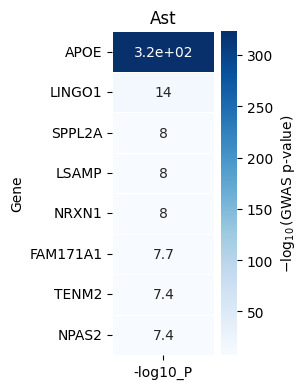

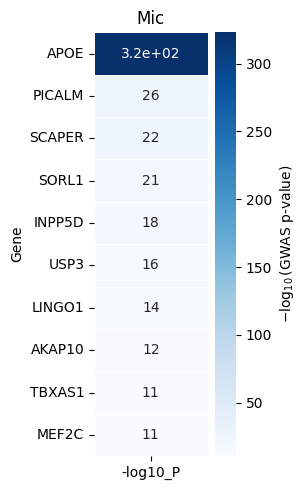

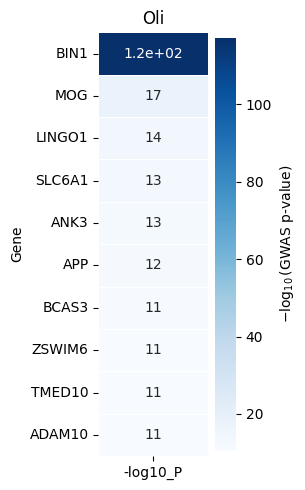

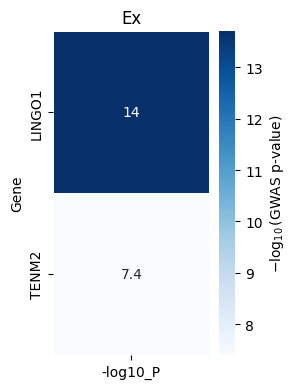

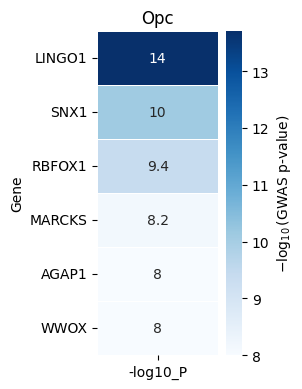

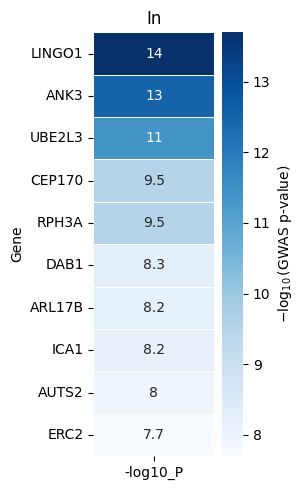

In [25]:
# snp gwas overlap heatmapts

import pandas as pd

import os
import joblib
from collections import defaultdict

# Define base path and cell types
base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_cerad"
ct_labels = {
    'Ast': 'Astrocytes',
    'Mic': 'Microglia',
    'In': 'Inhibitory Neurons',
    'Oli': 'Oligodendrocytes',
    'Opc': 'Oligodendrocyte Progenitor Cells',
    'Ex': 'Excitatory Neurons'
}
cell_types = list(ct_labels.keys())

# Dictionary to hold final predictors
predictive_genes_dict = {}

for cell_type in cell_types:
    print(f"Processing: {cell_type}")
    gene_presence = defaultdict(int)

    for split in range(1, 6):
        joblib_path = os.path.join(base_dir, cell_type, f"split_{split}", "maximal_classifier.joblib")
        if not os.path.exists(joblib_path):
            continue

        model = joblib.load(joblib_path)
        feature_names = model.feature_names_in_
        importances = model.feature_importances_

        for gene, imp in zip(feature_names, importances):
            gene_lower = gene.lower()
            if imp > 0 and not (
                gene_lower.startswith("age_death")
                or gene_lower.startswith("msex")
                or gene_lower.startswith("apoe_geno")
                or gene_lower.startswith("educ")
            ):
                gene_presence[gene] += 1

        # for gene, imp in zip(feature_names, importances):
        #     if imp > 0:
        #         gene_presence[gene] += 1

    # Keep genes that are non-zero in ≥ 3 splits
    final_predictors = [gene for gene, count in gene_presence.items() if count >= 2]
    predictive_genes_dict[cell_type] = final_predictors
    print(f"{cell_type}: {len(final_predictors)} predictive genes")

# This dictionary can now be used as your new top_25_dict equivalent
top_25_features_dict = predictive_genes_dict

# --- Load GWAS genes ---
gwas_path = '/n/scratch/users/a/adm808/MONDO_0004975_associations_export.tsv'
gwas_df = pd.read_csv(gwas_path, sep='\t', low_memory=False)

# Extract GWAS genes as uppercase
gwas_genes = set()
for genes in gwas_df['mappedGenes'].dropna():
    for g in genes.split(','):
        gwas_genes.add(g.strip().upper())

# --- Check overlap per cell type ---
gwas_overlap_dict = {}

for cell_type, pred_genes in predictive_genes_dict.items():
    pred_genes_upper = set(g.upper() for g in pred_genes)
    
    # Exact overlap
    overlap = pred_genes_upper & gwas_genes

    # Manual exception: include RASGEF1B if RASGEF1C in GWAS
    if "RASGEF1B" in pred_genes_upper and "RASGEF1C" in gwas_genes:
        overlap.add("RASGEF1B")

    gwas_overlap_dict[cell_type] = sorted(list(overlap))
    print(f"{cell_type}: {len(overlap)} genes overlap with GWAS (exact match + RASGEF1B manual inclusion)")
    print(overlap)

# --- Save CSV for supplement ---
all_types = []
for cell_type, overlap_genes in gwas_overlap_dict.items():
    for gene in overlap_genes:
        all_types.append({'CellType': cell_type, 'Gene': gene})

pd.DataFrame(all_types).to_csv('/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure10/CERAD_predictive_genes_GWAS_overlap_exact.csv', index=False)

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load overlap info
overlap_df = pd.read_csv('/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure10/CERAD_predictive_genes_GWAS_overlap_exact.csv')
overlap_genes = set(overlap_df['Gene'].str.upper())

# Load GWAS data
gwas_path = '/n/scratch/users/a/adm808/MONDO_0004975_associations_export.tsv'
gwas_df = pd.read_csv(gwas_path, sep='\t', low_memory=False)

# Create GWAS gene set
gwas_gene_set = set(
    g.strip().upper()
    for genes in gwas_df['mappedGenes'].dropna()
    for g in genes.split(',')
)

# Add RASGEF1C if needed
if "RASGEF1B" in overlap_genes and "RASGEF1B" in gwas_gene_set:
    print("Adding RASGEF1C manually to overlap genes.")
    overlap_genes.add("RASGEF1B")

gw_sig_thr = 5e-8
N = 10  # Top N genes per cell type

rows = []
for _, row in gwas_df.iterrows():
    pval = float(row['pValue']) if row['pValue'] != 'NR' else None
    loc = row['locations']
    genes = [g.strip().upper() for g in str(row['mappedGenes']).split(',') if g]
    
    for gene in genes:
        if gene in overlap_genes and pval is not None and pval > 0:
            cell_type_list = overlap_df.loc[overlap_df['Gene'].str.upper() == gene, 'CellType'].unique()
            # If RASGEF1C was not in overlap_df originally, assign all cell types where RASGEF1B was present
            if len(cell_type_list) == 0 and gene == "RASGEF1B":
                cell_type_list = overlap_df.loc[overlap_df['Gene'].str.upper() == "RASGEF1B", 'CellType'].unique()
            
            for cell_type in cell_type_list:
                rows.append({
                    'Gene': gene,
                    'CellType': cell_type,
                    'GWAS_P': pval,
                    '-log10_P': -np.log10(pval)
                })

df_plot = pd.DataFrame(rows)

# Deduplicate: keep only the lowest p-value per (Gene, CellType)
df_plot = df_plot.sort_values('GWAS_P').drop_duplicates(subset=['Gene', 'CellType'], keep='first')

# --- Plot separate heatmaps per cell type ---
for cell_type in df_plot['CellType'].unique():
    sub = df_plot[df_plot['CellType'] == cell_type]
    
    # Take top N significant genes
    top_sub = sub[sub['GWAS_P'] < gw_sig_thr].sort_values('GWAS_P').head(N)
    
    if top_sub.empty:
        print(f"Skipping {cell_type}: no significant genes.")
        continue

    # Create DataFrame for heatmap
    heatmap_df = top_sub[['Gene', '-log10_P']].set_index('Gene')
    heatmap_df = heatmap_df.sort_values('-log10_P', ascending=False)

    plt.figure(figsize=(3, max(4, 0.5 * len(heatmap_df))))
    sns.heatmap(
        heatmap_df,
        annot=True,
        cmap='Blues',
        cbar_kws={'label': r'$-\log_{10}$(GWAS p-value)'},
        linewidths=0.5
    )
    plt.title(f"{cell_type}")
    plt.ylabel("Gene")
    plt.xlabel("")
    plt.tight_layout()
    plt.savefig(f"/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure10/cerad_gwas_heatmap_{cell_type}_top{N}.png", dpi=300)
    plt.show()


/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.5.1 w

Ast: 104 predictors from /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_cerad


/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.5.1 wh

Mic: 422 predictors from /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_cerad


/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.5.1 wh

In: 121 predictors from /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_cerad
Oli: 557 predictors from /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_cerad


/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.5.1 wh

Opc: 75 predictors from /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_cerad


/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.5.1 wh

Ex: 18 predictors from /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_cerad
Ast: 175 predictors from /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new
Mic: 466 predictors from /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new
In: 108 predictors from /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new
Oli: 621 predictors from /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new
Opc: 835 predictors from /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new
Ex: 162 predictors from /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new


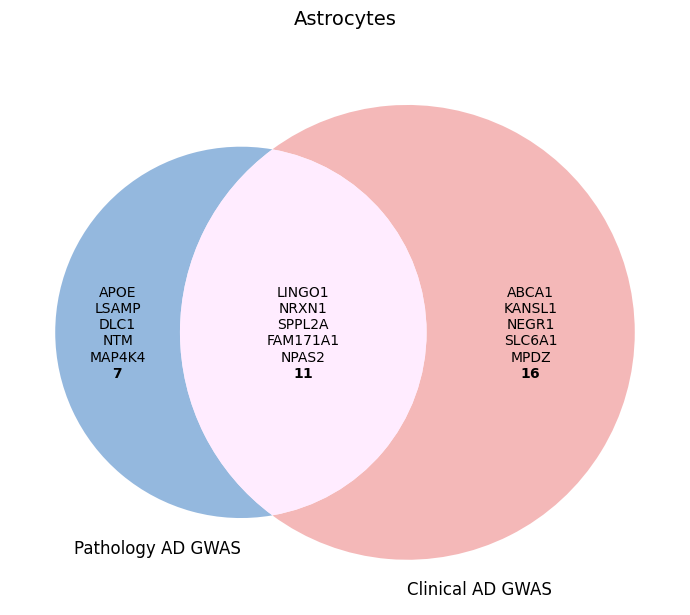

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure10/gwas_overlap_venn_Ast.png


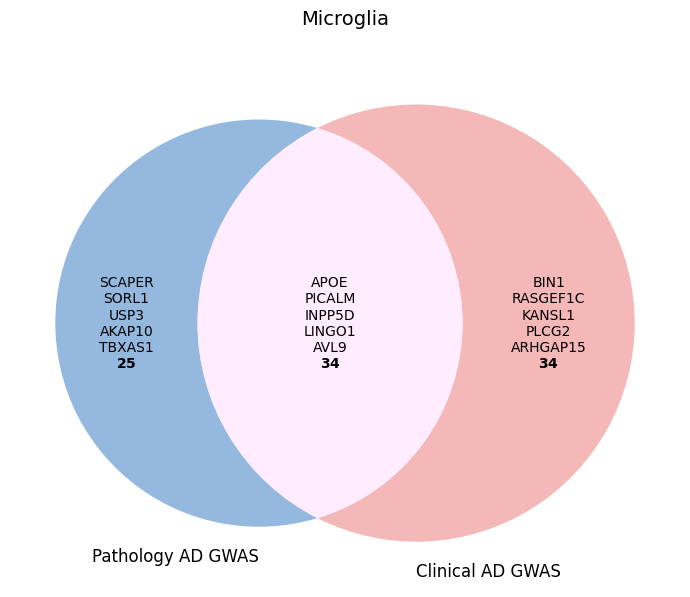

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure10/gwas_overlap_venn_Mic.png


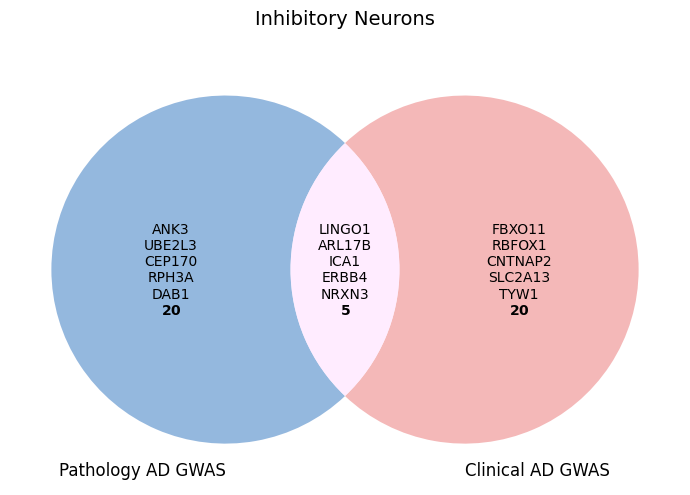

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure10/gwas_overlap_venn_In.png


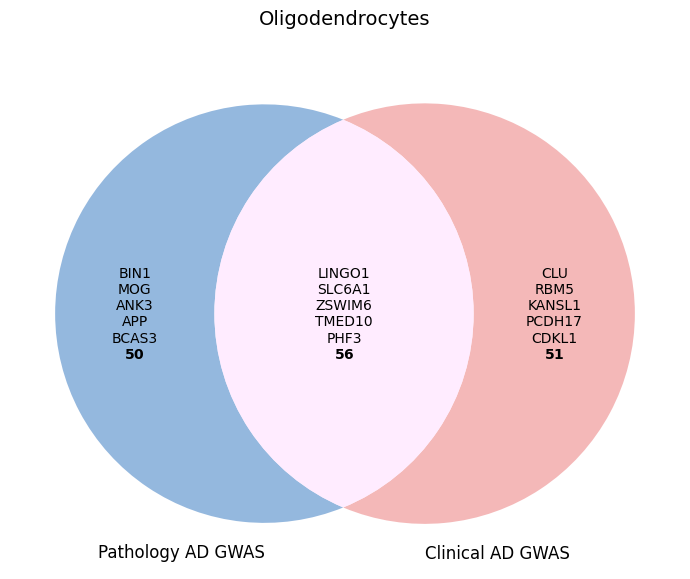

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure10/gwas_overlap_venn_Oli.png


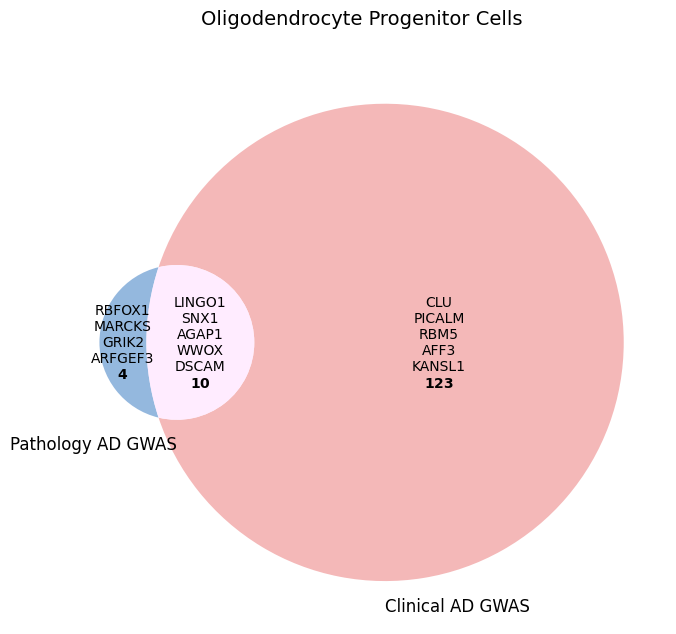

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure10/gwas_overlap_venn_Opc.png


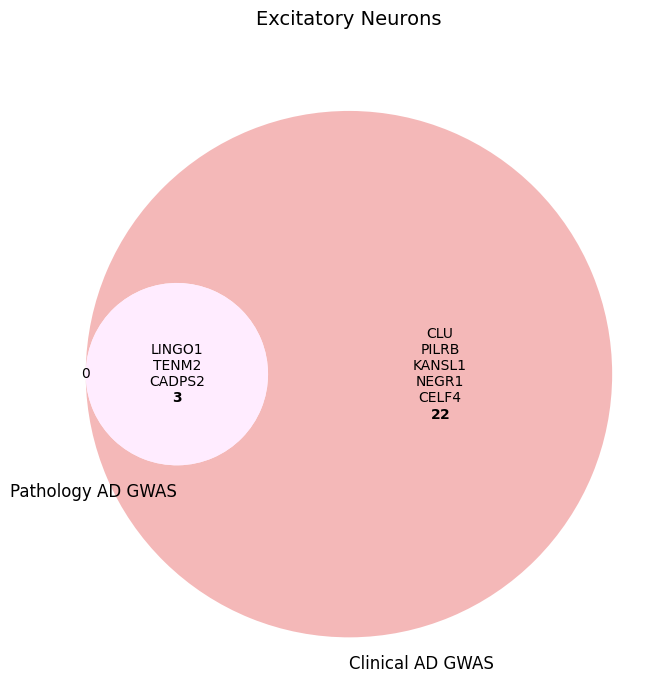

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure10/gwas_overlap_venn_Ex.png


In [8]:
# Two-way Venns per cell type: Pathology AD GWAS vs Clinical AD GWAS
# Labels show counts + top <=5 genes ranked by smallest GWAS p-value.

import os
import joblib
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# ================= CONFIG =================
cerad_base_dir    = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_cerad"
clinical_base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new"
gwas_path         = "/n/scratch/users/a/adm808/MONDO_0004975_associations_export.tsv"

output_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure10/"
os.makedirs(output_dir, exist_ok=True)

ct_labels = {
    'Ast': 'Astrocytes',
    'Mic': 'Microglia',
    'In': 'Inhibitory Neurons',
    'Oli': 'Oligodendrocytes',
    'Opc': 'Oligodendrocyte Progenitor Cells',
    'Ex': 'Excitatory Neurons'
}
cell_types = list(ct_labels.keys())

min_splits_required = 2
split_indices = range(1, 6)
exclude_prefixes = ("age_death", "msex", "apoe_geno", "educ")

# Optional: treat RASGEF1B as present in GWAS if RASGEF1C is in GWAS
apply_rasgef1b_equivalence = True

plt.rcParams.update({"font.size": 10})

# ================= HELPERS =================
def load_predictors(base_dir):
    preds = {}
    for ct in cell_types:
        gene_presence = defaultdict(int)
        for split in split_indices:
            p = os.path.join(base_dir, ct, f"split_{split}", "maximal_classifier.joblib")
            if not os.path.exists(p):
                continue
            model = joblib.load(p)
            feature_names = getattr(model, "feature_names_in_", None)
            importances   = getattr(model, "feature_importances_", None)
            if feature_names is None or importances is None:
                print(f"[WARN] Missing attrs in {p}; skipping this split.")
                continue
            for gene, imp in zip(feature_names, importances):
                if imp <= 0:
                    continue
                gl = str(gene).lower()
                if any(gl.startswith(pref) for pref in exclude_prefixes):
                    continue
                gene_presence[str(gene).upper()] += 1
        preds[ct] = {g for g, c in gene_presence.items() if c >= min_splits_required}
        print(f"{ct}: {len(preds[ct])} predictors from {base_dir}")
    return preds

def load_gwas_gene_pvals(gwas_tsv):
    """Return: set_of_genes, dict gene->best_pval (min p across rows; None if NR)."""
    df = pd.read_csv(gwas_tsv, sep="\t", low_memory=False)
    gene_to_p = {}
    for _, row in df.dropna(subset=["mappedGenes"]).iterrows():
        raw_p = row.get("pValue", None)
        try:
            pval = float(raw_p) if raw_p != "NR" else None
        except Exception:
            pval = None
        for g in str(row["mappedGenes"]).split(","):
            g = g.strip().upper()
            if not g:
                continue
            # keep the most significant (smallest) p-value per gene
            if g not in gene_to_p or (
                pval is not None and (gene_to_p[g] is None or pval < gene_to_p[g])
            ):
                gene_to_p[g] = pval
    genes = set(gene_to_p.keys())
    return genes, gene_to_p

def rank_genes_by_p(genes, pmap):
    # sort by p asc; None goes to end
    return sorted(genes, key=lambda g: (1 if pmap.get(g) is None else 0, pmap.get(g, 1e9), g))

# def label_region(label_obj, genes, pmap, top_k=5):
#     if label_obj is None:
#         return
#     if not genes:
#         label_obj.set_text("0")
#         return
#     top = rank_genes_by_p(list(genes), pmap)[:top_k]
#     label_obj.set_text(f"{len(genes)}\n" + "\n".join(top))

# # ================= MAIN =================
# def main():
#     cerad_preds    = load_predictors(cerad_base_dir)
#     clinical_preds = load_predictors(clinical_base_dir)
#     gwas_genes, gwas_p = load_gwas_gene_pvals(gwas_path)

#     for ct in cell_types:
#         # Subset BOTH predictor sets to GWAS genes first (so only two sets remain)
#         A = cerad_preds.get(ct, set())    & gwas_genes  # Pathology AD GWAS
#         B = clinical_preds.get(ct, set()) & gwas_genes  # Clinical AD GWAS

#         # Make 2-set venn
#         plt.figure(figsize=(7, 7))
#         v = venn2([A, B],
#                   set_labels=("Pathology AD GWAS", "Clinical AD GWAS"),
#                   set_colors=("#7aa6d6", "#f2a6a6"),
#                   alpha=0.8)

#         # Left-only, right-only, overlap
#         A_only = A - B
#         B_only = B - A
#         AB     = A & B

#         label_region(v.get_label_by_id('10'), A_only, gwas_p, top_k=5)
#         label_region(v.get_label_by_id('01'), B_only, gwas_p, top_k=5)
#         label_region(v.get_label_by_id('11'), AB,     gwas_p, top_k=5)

#         plt.title(ct_labels[ct], fontsize=14)
#         plt.tight_layout()
#         out_path = os.path.join(output_dir, f"gwas_overlap_venn_{ct}.png")
#         plt.savefig(out_path, dpi=300)
#         plt.show()
#         print(f"Saved: {out_path}")

def label_region(label_obj, genes, pmap, top_k=5):
    if label_obj is None:
        return
    if not genes:
        label_obj.set_text("0")
        return
    top = rank_genes_by_p(list(genes), pmap)[:top_k]
    # Show top genes first, then bold total count (no parentheses)
    label_obj.set_text("\n".join(top) + f"\n" + r"$\mathbf{" + str(len(genes)) + "}$")

# ================= MAIN =================
def main():
    cerad_preds    = load_predictors(cerad_base_dir)
    clinical_preds = load_predictors(clinical_base_dir)
    gwas_genes, gwas_p = load_gwas_gene_pvals(gwas_path)

    for ct in cell_types:
        A = cerad_preds.get(ct, set())    & gwas_genes
        B = clinical_preds.get(ct, set()) & gwas_genes

        plt.figure(figsize=(7, 7))
        v = venn2([A, B],
                  set_labels=("Pathology AD GWAS", "Clinical AD GWAS"),
                  set_colors=("#7aa6d6", "#f2a6a6"),
                  alpha=0.8)

        A_only = A - B
        B_only = B - A
        AB     = A & B

        label_region(v.get_label_by_id('10'), A_only, gwas_p, top_k=5)
        label_region(v.get_label_by_id('01'), B_only, gwas_p, top_k=5)
        label_region(v.get_label_by_id('11'), AB,     gwas_p, top_k=5)

        # Fixed title position
        plt.title(ct_labels[ct], fontsize=14, y=1.05)

        plt.tight_layout()
        out_path = os.path.join(output_dir, f"gwas_overlap_venn_{ct}.png")
        # plt.savefig(out_path, dpi=300)
        plt.show()
        print(f"Saved: {out_path}")

if __name__ == "__main__":
    main()